Decision_Tree

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
df = pd.read_csv('cleaned_f1_data.csv')

In [4]:
df.head()

,Season,Round,Race Name,Date,Circuit,Country,Latitude,Longitude,Driver,Driver Nationality,Driver Age,Constructor,Grid Position,Race Position,Points Earned,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status
0,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Nino Farina,Italian,44,Alfa Romeo,1,1,9.0,90.239026,-1,70,Finished
1,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Reg Parnell,British,39,Alfa Romeo,4,3,4.0,90.239026,-1,70,Finished
2,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Yves Cabantous,French,46,Talbot-Lago,6,4,3.0,90.239026,-1,68,+2 Laps
3,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Louis Rosier,French,45,Talbot-Lago,9,5,2.0,90.239026,-1,68,+2 Laps
4,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Bob Gerard,British,36,ERA,13,6,0.0,90.239026,-1,67,+3 Laps


STEP-2 DROP irrelevant columns

In [5]:
to_drop = ['Season', 'Round', 'Race Name', 'Date', 'Country',
           'Driver Nationality', 'Driver', 'Points Earned',
           'Latitude', 'Longitude']

df = df.drop(columns=to_drop, errors='ignore')
print("Remaining columns:", list(df.columns))
print("Shape after dropping:", df.shape)

Remaining columns: ['Circuit', 'Driver Age', 'Constructor', 'Grid Position', 'Race Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed', 'Status']
Shape after dropping: (6939, 9)


 Step 3 — Feature Engineering (Binary Features)

In [6]:
df['Grid Position Binary'] = (df['Grid Position'] <= 10).astype(int)
df['Driver Age Binary'] = (df['Driver Age'] > 30).astype(int)
df['Laps Completed Binary'] = (df['Laps Completed'] > 50).astype(int)

# Drop the original columns now that we have binary versions
df = df.drop(['Grid Position', 'Driver Age', 'Laps Completed'], axis=1)

print("New binary features added.")
print("Columns now:", list(df.columns))

New binary features added.
Columns now: ['Circuit', 'Constructor', 'Race Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Status', 'Grid Position Binary', 'Driver Age Binary', 'Laps Completed Binary']


Step 4 -  Encode Categorical Columns
 Converting text columns (`Circuit`, `Constructor`, `Status`) into numbers using OrdinalEncoder.

In [7]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

categories_list = [df[col].unique().tolist() for col in categorical_cols]
encoder = OrdinalEncoder(categories=categories_list)
df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

print("\nEncoding complete. Sample:")
print(df.head())

Categorical columns to encode: ['Circuit', 'Constructor', 'Status']

Encoding complete. Sample:
   Circuit  Constructor  Race Position  Fastest Lap (s)  Fastest Lap Rank  \
0      0.0          0.0              1        90.239026                -1   
1      0.0          0.0              3        90.239026                -1   
2      0.0          1.0              4        90.239026                -1   
3      0.0          1.0              5        90.239026                -1   
4      0.0          2.0              6        90.239026                -1   

   Status  Grid Position Binary  Driver Age Binary  Laps Completed Binary  
0     0.0                     1                  1                      1  
1     0.0                     1                  1                      1  
2     1.0                     1                  1                      1  
3     1.0                     1                  1                      1  
4     2.0                     0                  1           

Step 5: Define the Target Variable

**What:** Creating a binary target column `Position_Category` — what the model will try to predict.

**Why:** Instead of predicting the exact finishing position (1st through 33rd), we simplify it into a binary classification problem:
- **Points (1)** → driver finishes in the Top 10 and scores championship points
- **No Points (0)** → driver finishes outside Top 10

This is the most meaningful and practically useful framing: teams and fans care most about whether a driver scores points, not the exact position. It also gives us a more balanced class distribution than trying to predict the exact winner (only ~5% of rows).

In [8]:
df['Position_Category'] = (df['Race Position'] <= 10).astype(int)

# Drop original Race Position column — it would leak the answer
df = df.drop(['Race Position'], axis=1)

print("Target variable distribution:")
print(df['Position_Category'].value_counts())
print(f"\n0 = No Points (outside Top 10)")
print(f"1 = Points (Top 10 finish)")

# Check class balance
total = len(df)
points = df['Position_Category'].sum()
print(f"\nClass balance: {points/total*100:.1f}% Points finishers, {(total-points)/total*100:.1f}% No Points")

Target variable distribution:
Position_Category
0    3590
1    3349
Name: count, dtype: int64

0 = No Points (outside Top 10)
1 = Points (Top 10 finish)

Class balance: 48.3% Points finishers, 51.7% No Points


 Step 6 — Train/Test Split (80/20)

In [9]:
X = df.drop(['Position_Category'], axis=1)
y = df['Position_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Features:     {X_train.shape[1]} columns")
print(f"\nFeature names: {list(X.columns)}")

Training set: 5551 rows
Test set:     1388 rows
Features:     8 columns

Feature names: ['Circuit', 'Constructor', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Status', 'Grid Position Binary', 'Driver Age Binary', 'Laps Completed Binary']


 Step 7 — Decision Tree Model 1: Default Parameters

In [12]:
dt_model_1 = DecisionTreeClassifier(random_state=42)
dt_model_1.fit(X_train, y_train)
y_pred_1 = dt_model_1.predict(X_test)

print("=" * 50)
print("MODEL 1 — Default Decision Tree")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_1):.4f}")
print(f"Tree Depth: {dt_model_1.get_depth()}")
print(f"Number of Leaves: {dt_model_1.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_1, target_names=['No Points', 'Points']))

MODEL 1 — Default Decision Tree
Accuracy: 0.8552
Tree Depth: 24
Number of Leaves: 809

Classification Report:
              precision    recall  f1-score   support

   No Points       0.86      0.86      0.86       728
      Points       0.85      0.85      0.85       660

    accuracy                           0.86      1388
   macro avg       0.85      0.85      0.85      1388
weighted avg       0.86      0.86      0.86      1388



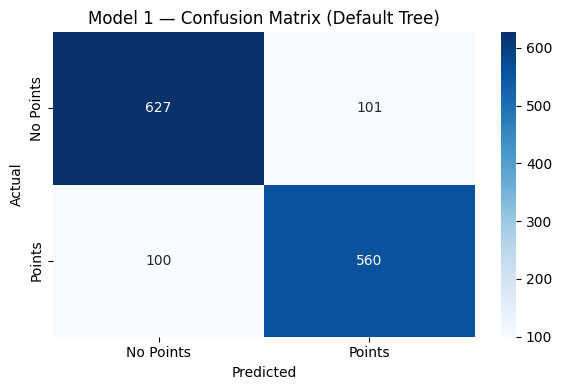

In [13]:
cm1 = confusion_matrix(y_test, y_pred_1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 1 — Confusion Matrix (Default Tree)')
plt.tight_layout()
plt.show()

 Step 9 — Decision Tree Model 2: Entropy + Max Depth = 6

In [14]:
dt_model_2 = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=6)
dt_model_2.fit(X_train, y_train)
y_pred_2 = dt_model_2.predict(X_test)

print("=" * 50)
print("MODEL 2 — Entropy + Max Depth 6")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_2):.4f}")
print(f"Tree Depth: {dt_model_2.get_depth()}")
print(f"Number of Leaves: {dt_model_2.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_2, target_names=['No Points', 'Points']))

MODEL 2 — Entropy + Max Depth 6
Accuracy: 0.8876
Tree Depth: 6
Number of Leaves: 53

Classification Report:
              precision    recall  f1-score   support

   No Points       0.90      0.89      0.89       728
      Points       0.88      0.88      0.88       660

    accuracy                           0.89      1388
   macro avg       0.89      0.89      0.89      1388
weighted avg       0.89      0.89      0.89      1388



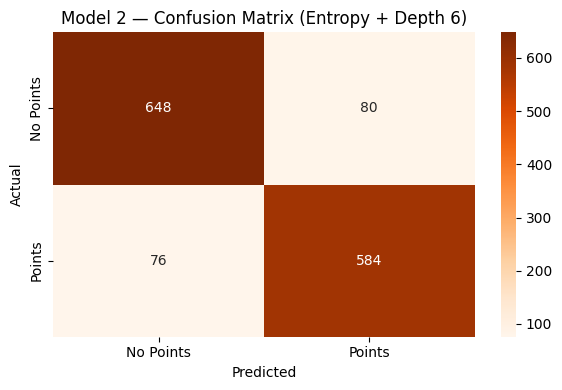

In [15]:
cm2 = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 2 — Confusion Matrix (Entropy + Depth 6)')
plt.tight_layout()
plt.show()

step-10
 Decision Tree Model 3: Gini + Min Samples Split = 20

In [16]:
dt_model_3 = DecisionTreeClassifier(random_state=42, criterion='gini', min_samples_split=20)
dt_model_3.fit(X_train, y_train)
y_pred_3 = dt_model_3.predict(X_test)

print("=" * 50)
print("MODEL 3 — Gini + Min Samples Split 20")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_3):.4f}")
print(f"Tree Depth: {dt_model_3.get_depth()}")
print(f"Number of Leaves: {dt_model_3.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_3, target_names=['No Points', 'Points']))

MODEL 3 — Gini + Min Samples Split 20
Accuracy: 0.8746
Tree Depth: 18
Number of Leaves: 283

Classification Report:
              precision    recall  f1-score   support

   No Points       0.89      0.87      0.88       728
      Points       0.86      0.88      0.87       660

    accuracy                           0.87      1388
   macro avg       0.87      0.87      0.87      1388
weighted avg       0.87      0.87      0.87      1388



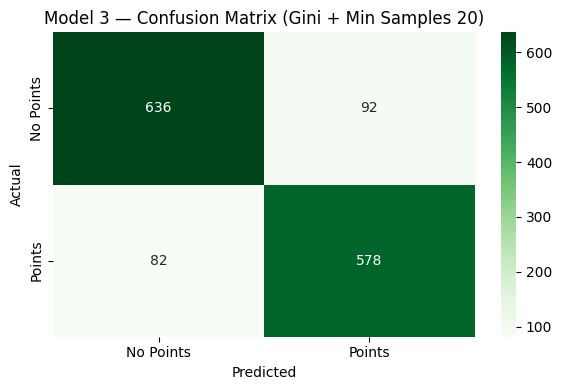

In [17]:
cm3 = confusion_matrix(y_test, y_pred_3)
plt.figure(figsize=(6, 4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Points', 'Points'],
            yticklabels=['No Points', 'Points'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 3 — Confusion Matrix (Gini + Min Samples 20)')
plt.tight_layout()
plt.show()

 Step 11 — Model Comparison

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Model 1 (Default)', 'Model 2 (Entropy+Depth6)', 'Model 3 (Gini+MinSplit20)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_1),
        accuracy_score(y_test, y_pred_2),
        accuracy_score(y_test, y_pred_3)
    ],
    'Precision': [
        precision_score(y_test, y_pred_1),
        precision_score(y_test, y_pred_2),
        precision_score(y_test, y_pred_3)
    ],
    'Recall': [
        recall_score(y_test, y_pred_1),
        recall_score(y_test, y_pred_2),
        recall_score(y_test, y_pred_3)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_1),
        f1_score(y_test, y_pred_2),
        f1_score(y_test, y_pred_3)
    ],
    'Tree Depth': [
        dt_model_1.get_depth(),
        dt_model_2.get_depth(),
        dt_model_3.get_depth()
    ]
})

print(results.to_string(index=False))

                    Model  Accuracy  Precision   Recall  F1 Score  Tree Depth
        Model 1 (Default)  0.855187   0.847201 0.848485  0.847843          24
 Model 2 (Entropy+Depth6)  0.887608   0.879518 0.884848  0.882175           6
Model 3 (Gini+MinSplit20)  0.874640   0.862687 0.875758  0.869173          18


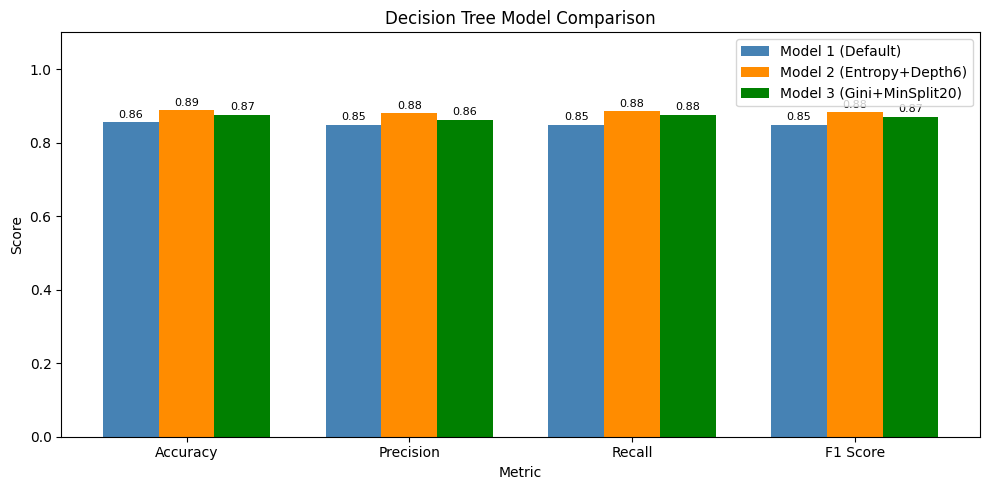

In [19]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, results.iloc[0][metrics], width, label='Model 1 (Default)', color='steelblue')
bars2 = ax.bar(x, results.iloc[1][metrics], width, label='Model 2 (Entropy+Depth6)', color='darkorange')
bars3 = ax.bar(x + width, results.iloc[2][metrics], width, label='Model 3 (Gini+MinSplit20)', color='green')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Decision Tree Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(bars3, fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()

Step 11 — Visualise the Decision Trees

Model 1

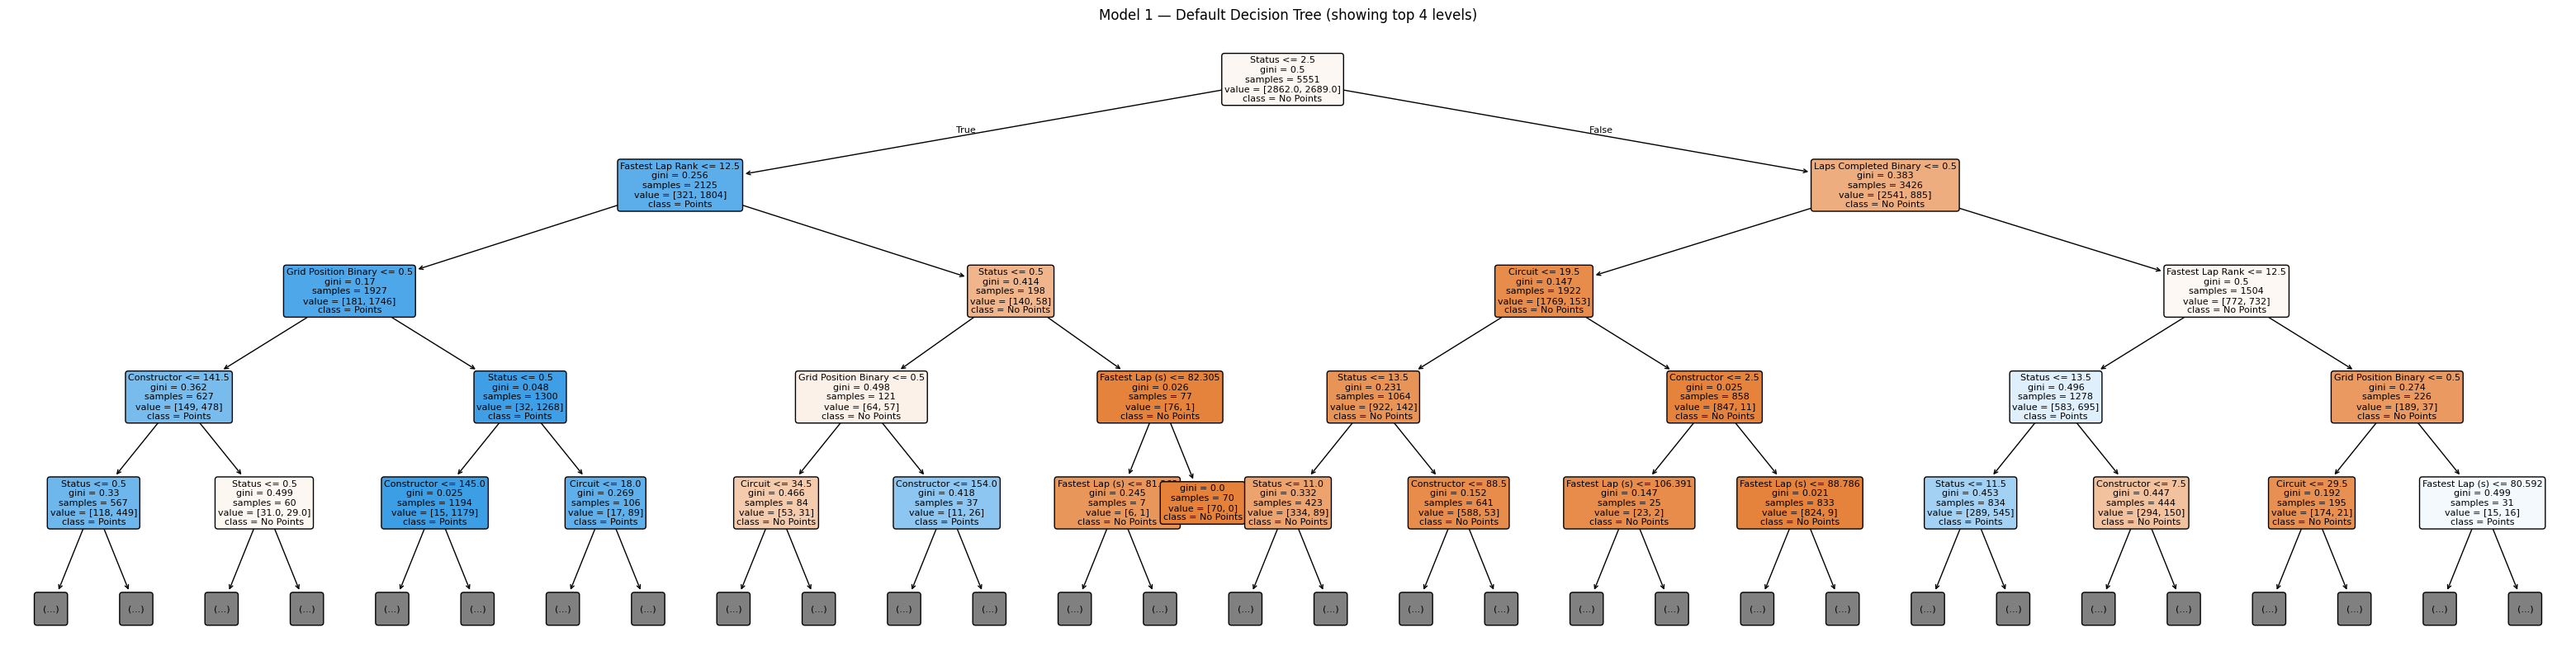

In [20]:
feature_names = X_train.columns.values
class_names = ['No Points', 'Points']

plt.figure(figsize=(40, 10))
plot_tree(dt_model_1,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=4)  # Show only top 4 levels for readability
plt.title('Model 1 — Default Decision Tree (showing top 4 levels)')
plt.show()

Model 2

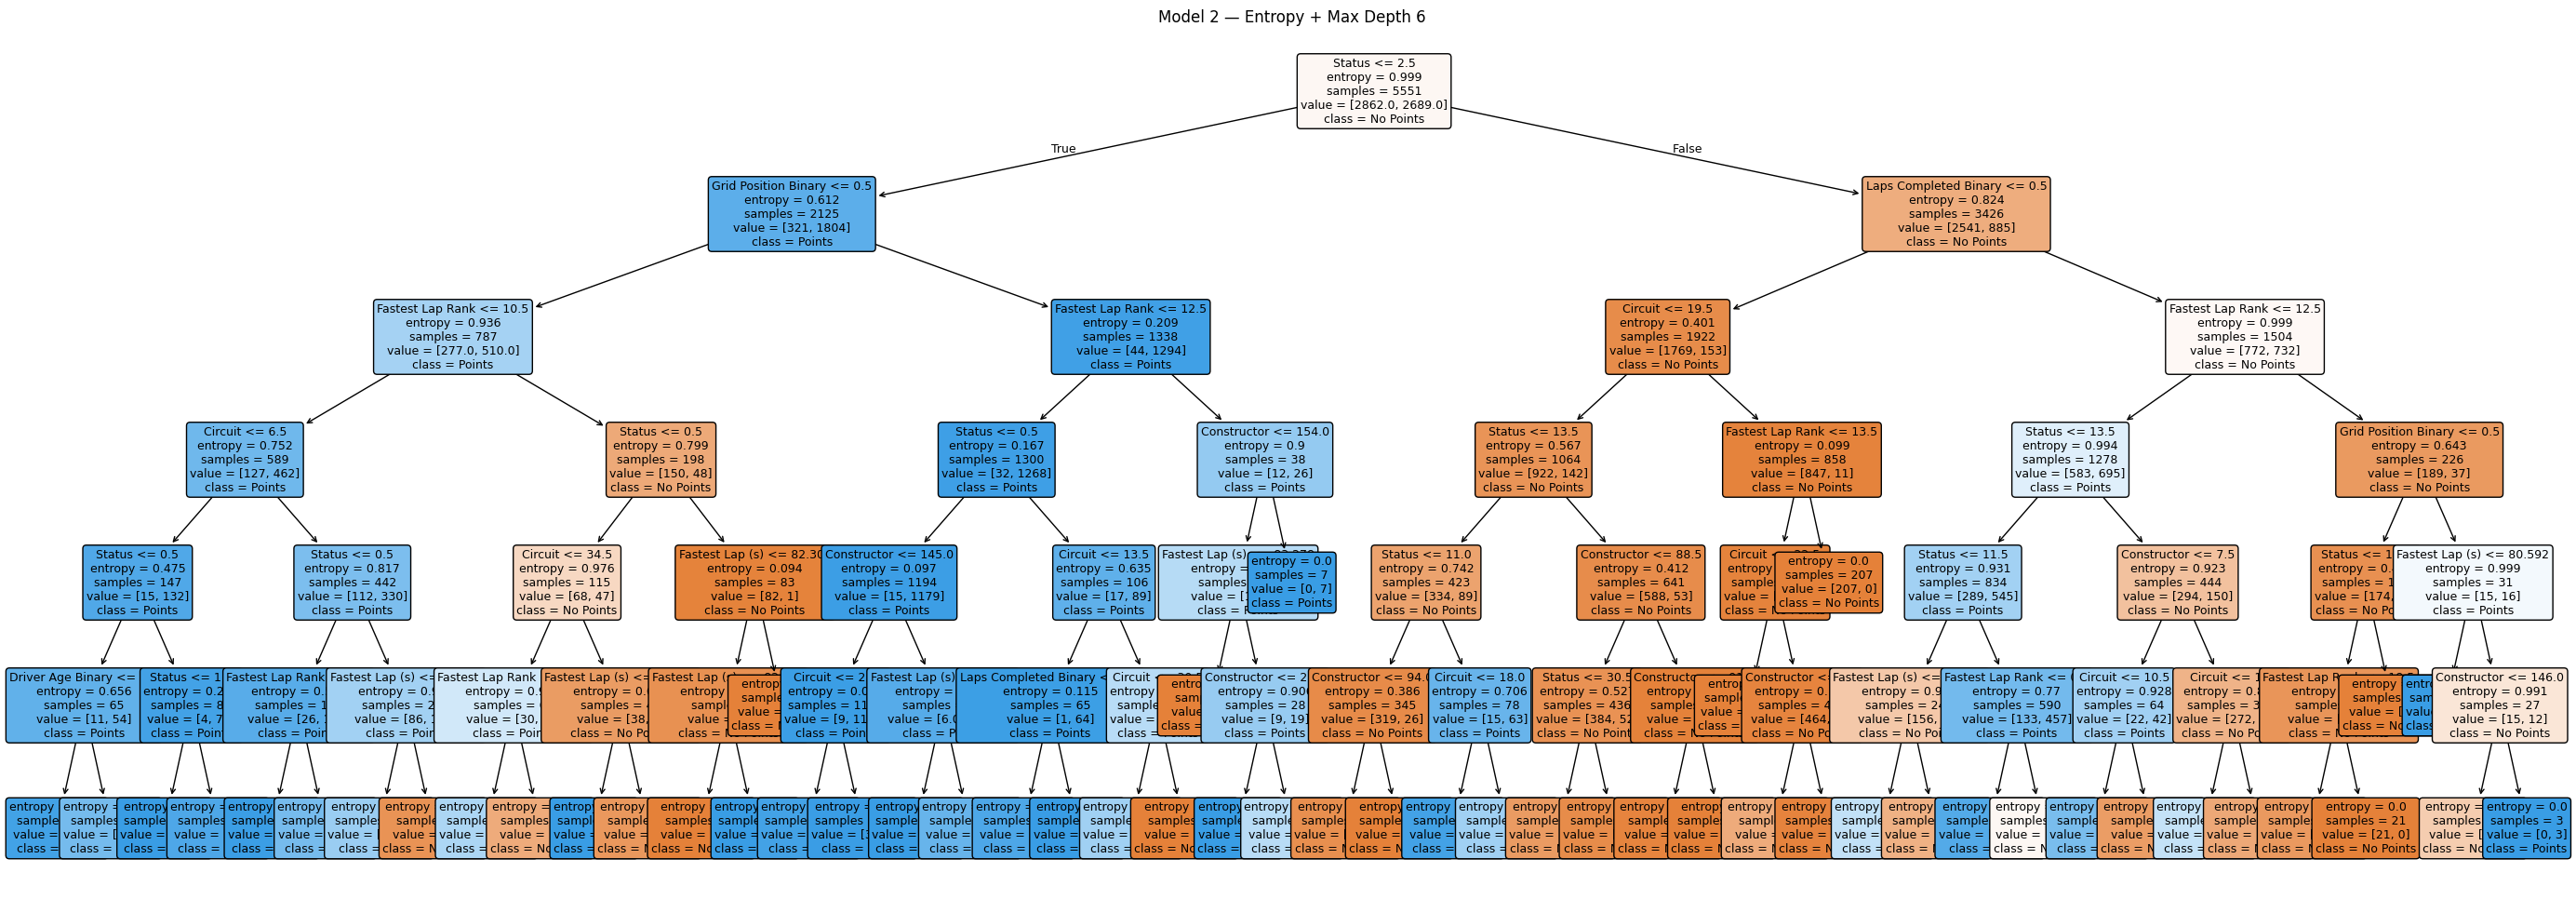

In [21]:
# Model 2 Tree (max_depth=6, more readable)
plt.figure(figsize=(35, 12))
plot_tree(dt_model_2,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=9)
plt.title('Model 2 — Entropy + Max Depth 6')
plt.show()

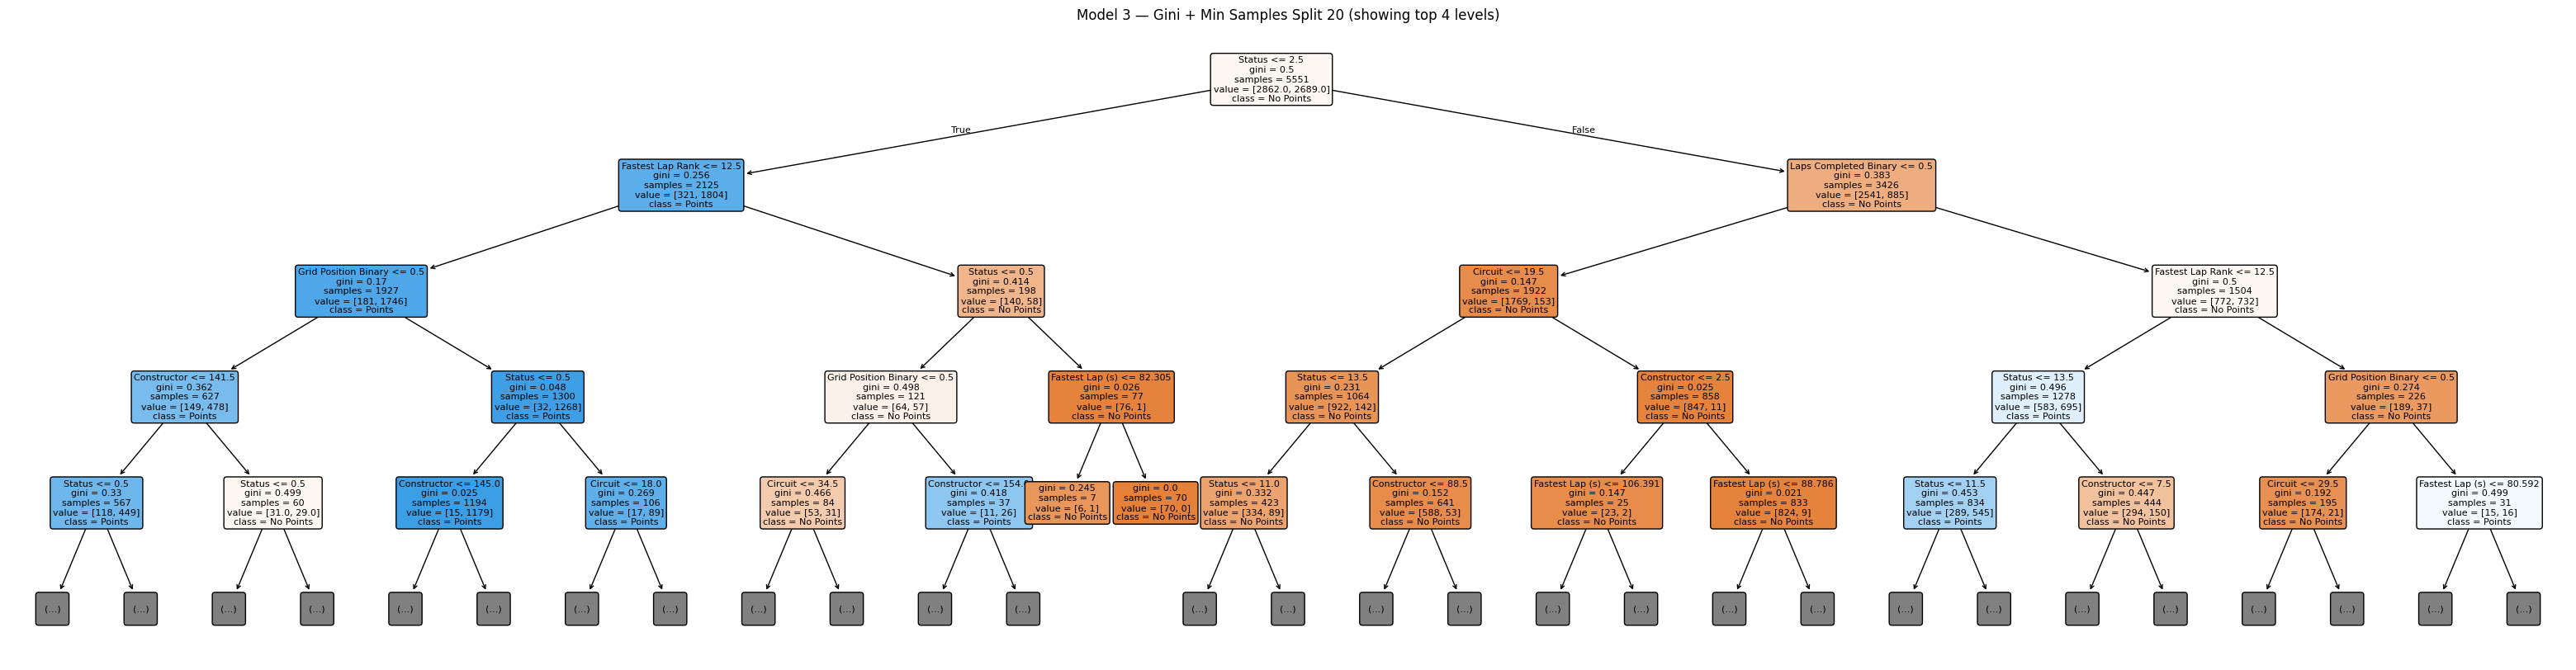

In [22]:
# Model 3 Tree
plt.figure(figsize=(40, 10))
plot_tree(dt_model_3,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=4)
plt.title('Model 3 — Gini + Min Samples Split 20 (showing top 4 levels)')
plt.show()

Step 12 — Feature Importance

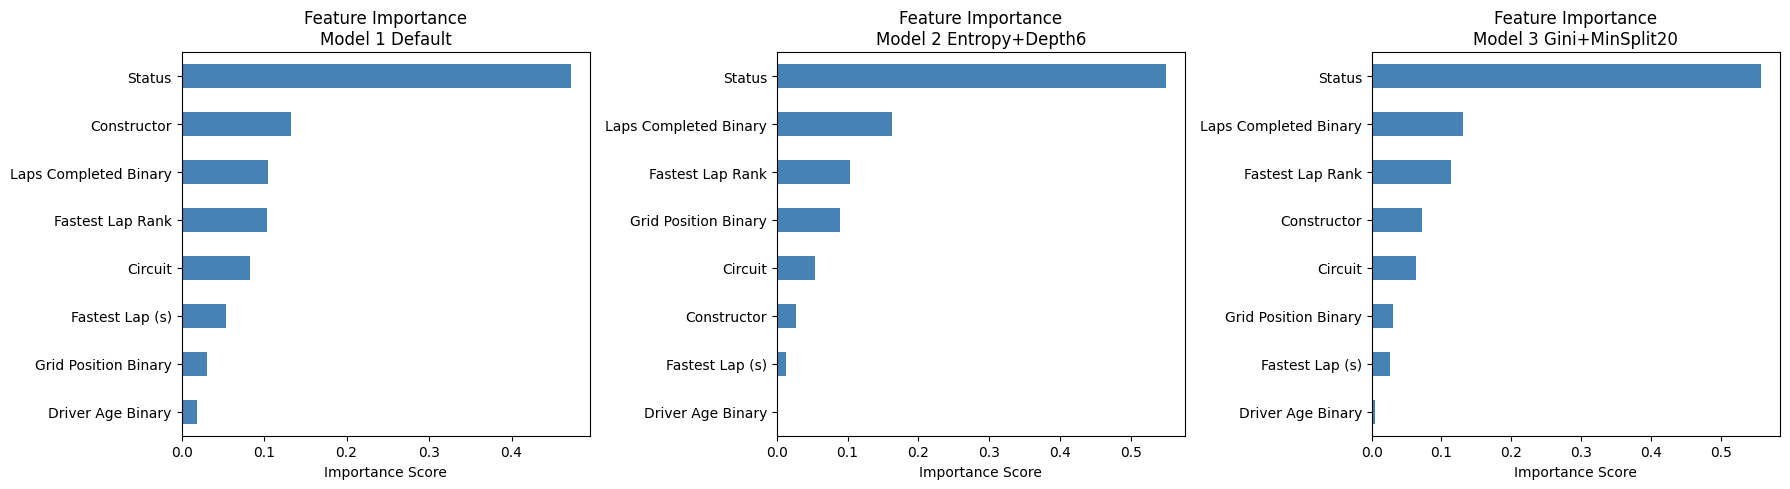

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (model, name) in enumerate([(dt_model_1, 'Model 1 Default'),
                                     (dt_model_2, 'Model 2 Entropy+Depth6'),
                                     (dt_model_3, 'Model 3 Gini+MinSplit20')]):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Feature Importance\n{name}')
    axes[i].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()